# Decision Tree Model with Balanced Class Weight & Regularization (High Recall Model) #

This standalone notebook trains the regularized, class-balanced Decision Tree model (`class_weight='balanced'`, `max_depth=8`, `min_samples_leaf=50`) on the cleaned gastric cancer dataset. It outputs the exact high-recall metrics (Recall = 0.6787), classification report, confusion matrix, and ROC/PR curves.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, f1_score, precision_score, recall_score,
    average_precision_score, accuracy_score, balanced_accuracy_score
)

## 1. Load Cleaned Dataset ##

In [2]:
df = pd.read_csv("../Dataset/cleaned_gcs_kushal.csv")

# Convert boolean one-hot columns to integers
for col in df.select_dtypes(include="bool").columns:
    df[col] = df[col].astype(int)

df.head()

,age,gender,family_history,smoking_habits,alcohol_consumption,helicobacter_pylori_infection,dietary_habits,endoscopic_images,biopsy_results,ct_scan,...,label,existing_conditions_Chronic Gastritis,existing_conditions_Diabetes,existing_conditions_Unknown,mature_mirna_id_MIR123_1,mature_mirna_id_MIR234_2,mature_mirna_id_MIR345_3,target_symbol_CDH1,target_symbol_KRAS,target_symbol_TP53
0,43,1,1,0,0,0,0,0,0,0,...,0,1,0,0,1,0,0,0,0,1
1,86,0,1,0,0,1,1,0,0,0,...,0,0,1,0,0,1,0,0,0,1
2,68,1,0,1,1,0,1,0,0,0,...,0,0,0,1,0,0,1,0,1,0
3,57,0,0,0,0,1,1,0,0,0,...,0,1,0,0,1,0,0,0,1,0
4,33,1,0,1,1,0,1,1,0,0,...,0,0,1,0,1,0,0,1,0,0


## 2. Train-Validation-Test Split ##

In [3]:
X = df.drop("label", axis=1)
y = df["label"]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.20, random_state=42, stratify=y_train_full
)

print(f"Train set: {X_train.shape}, Val set: {X_val.shape}, Test set: {X_test.shape}")
print(f"Train class ratio — 0: {(y_train == 0).sum()}, 1: {(y_train == 1).sum()}")
print(f"Test class ratio  — 0: {(y_test == 0).sum()}, 1: {(y_test == 1).sum()}")

Train set: (135906, 29), Val set: (33977, 29), Test set: (42471, 29)
Train class ratio — 0: 122492, 1: 13414
Test class ratio  — 0: 38279, 1: 4192


## 3. Train Decision Tree Model (class_weight='balanced', max_depth=8, min_samples_leaf=50) ##

In [4]:
dt_balanced = DecisionTreeClassifier(
    class_weight="balanced",
    max_depth=8,
    min_samples_leaf=50,
    random_state=42
)
dt_balanced.fit(X_train, y_train)

y_pred = dt_balanced.predict(X_test)
y_prob = dt_balanced.predict_proba(X_test)[:, 1]

## 4. Final Test Set Metrics ##

In [5]:
acc = accuracy_score(y_test, y_pred)
bal_acc = balanced_accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, pos_label=1)
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

print("=" * 55)
print("FINAL TEST SET METRICS")
print("=" * 55)
print(f"Accuracy:           {acc:.4f}")
print(f"Balanced Accuracy:  {bal_acc:.4f}")
print(f"Precision (cancer): {prec:.4f}")
print(f"Recall (cancer):    {rec:.4f}")
print(f"F1-Score (cancer):  {f1:.4f}")
print(f"ROC-AUC:            {roc_auc:.4f}")
print(f"PR-AUC (AP):        {pr_auc:.4f}")
print("=" * 55)

FINAL TEST SET METRICS
Accuracy:           0.3583
Balanced Accuracy:  0.5009
Precision (cancer): 0.0989
Recall (cancer):    0.6787
F1-Score (cancer):  0.1727
ROC-AUC:            0.5015
PR-AUC (AP):        0.0989


## 5. Classification Report & Confusion Matrix ##


Classification Report:

               precision    recall  f1-score   support

No Cancer (0)       0.90      0.32      0.48     38279
   Cancer (1)       0.10      0.68      0.17      4192

     accuracy                           0.36     42471
    macro avg       0.50      0.50      0.32     42471
 weighted avg       0.82      0.36      0.45     42471

Confusion Matrix (raw counts):
[[12372 25907]
 [ 1347  2845]]


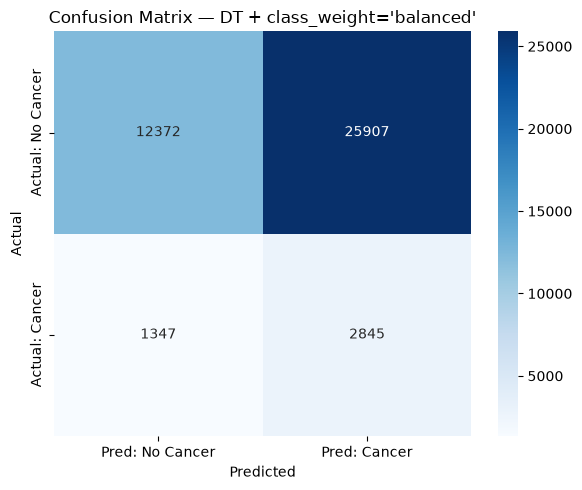

In [6]:
print("\nClassification Report:\n")
print(classification_report(
    y_test, y_pred,
    target_names=["No Cancer (0)", "Cancer (1)"],
    zero_division=0
))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix (raw counts):")
print(cm)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred: No Cancer", "Pred: Cancer"],
    yticklabels=["Actual: No Cancer", "Actual: Cancer"],
    ax=ax
)
ax.set_title("Confusion Matrix — DT + class_weight='balanced'")
ax.set_ylabel("Actual")
ax.set_xlabel("Predicted")
plt.tight_layout()
plt.show()

## 6. Classification Threshold Curves (ROC & PR) ##

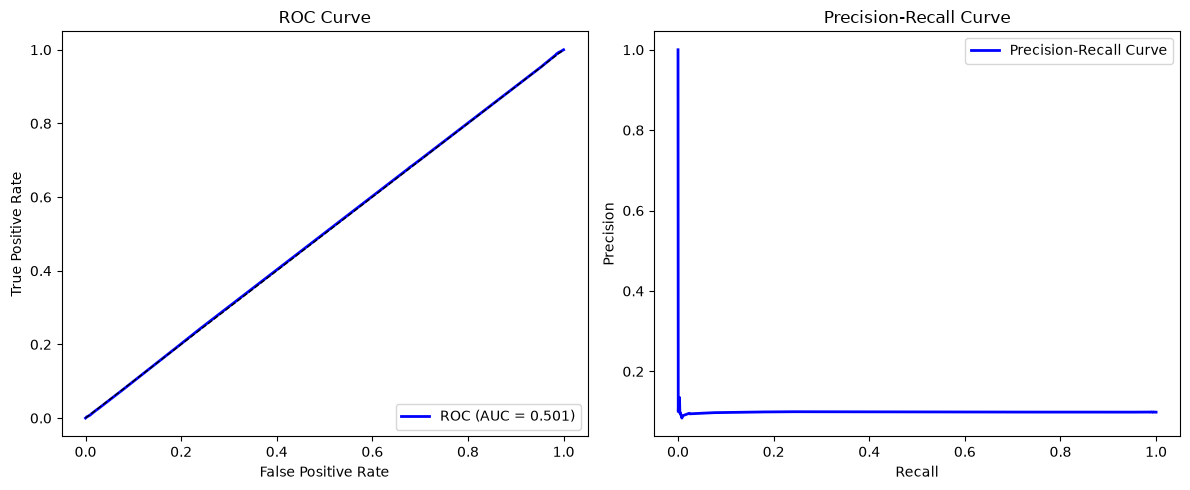

In [7]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(12, 5))

# ROC Curve
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc:.3f})", color="b", lw=2)
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")

# Precision-Recall Curve
plt.subplot(1, 2, 2)
plt.plot(recall, precision, label="Precision-Recall Curve", color="b", lw=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()